# Phase 3 - Machine Learning: K-Means Clustering
**Project:** AI-Based Analysis and Prediction of Student Clinic Visits

Two clustering analyses:
- **K-Means A** - Hostel risk profiling (10 hostels → risk tiers)
- **K-Means B** - Visit pattern discovery (5,799 visits → visit archetypes)

Outputs feed directly into Phase 4 (Regression) and Phase 5 (Dashboard).

---
## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from pymongo import MongoClient
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ── Plot style (matches EDA notebook) ────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#2d3148',
    'axes.labelcolor':  '#9ca3af',
    'xtick.color':      '#6b7280',
    'ytick.color':      '#6b7280',
    'text.color':       '#e5e7eb',
    'grid.color':       '#2d3148',
    'grid.linestyle':   '--',
    'grid.alpha':        0.5,
    'font.family':      'serif',
})
TEAL   = '#00c9a7'
BLUE   = '#0072ff'
AMBER  = '#f59e0b'
RED    = '#ff6b6b'
PURPLE = '#a78bfa'
PALETTE = [TEAL, BLUE, AMBER, RED, PURPLE, '#fb923c', '#6ee7b7']

# ── Model output folder ───────────────────────────────────────
os.makedirs('models', exist_ok=True)

print('Setup complete ✓')

Setup complete ✓


---
## 1. Load Data from MongoDB

In [2]:
client     = MongoClient('mongodb://localhost:27017/')
db         = client['UniMediTrend']
collection = db['clinic_logs']

df = pd.DataFrame(list(collection.find({}, {'_id': 0})))
df['visit_date'] = pd.to_datetime(df['visit_date'])

# Engineer original month FIRST
df['month'] = df['visit_date'].dt.month

# THEN engineer Cyclical Time
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

print(f'Loaded {len(df):,} records  |  Columns: {list(df.columns)}')
df.head()

Loaded 5,799 records  |  Columns: ['visit_date', 'level', 'gender', 'department', 'hostel', 'diagnosis', 'severity', 'month', 'month_sin', 'month_cos']


,visit_date,level,gender,department,hostel,diagnosis,severity,month,month_sin,month_cos
0,2024-01-15,200,Male,Electrical & Electronic Engineering,Gold Refinery Hall,Physical Injury,1,1,0.5,0.866025
1,2024-01-15,400,Female,Electrical & Electronic Engineering,The Point Hostel,Stress/Fatigue,3,1,0.5,0.866025
2,2024-01-15,400,Female,Computer Science & Engineering,Castle Gate,Food Poisoning,2,1,0.5,0.866025
3,2024-01-15,200,Male,Mining Engineering,Kabi's Hostel,Physical Injury,3,1,0.5,0.866025
4,2024-01-15,300,Male,Mining Engineering,Gold Refinery Hall,Stress/Fatigue,1,1,0.5,0.866025


## K-Means A — Hostel Risk Profiling

Unit of analysis: the **hostel** (10 rows).  
Each hostel is described by its illness percentage breakdown and average severity.  
Goal: group hostels into risk tiers that the clinic can act on.

### A1. Build the Hostel Profile Matrix

In [3]:
# === Illness % per hostel ===
# For each hostel: what % of its visits were each diagnosis?
# Using % not raw counts so hostel size doesn't dominate.
diagnosis_pct = (
    df.groupby(['hostel', 'diagnosis'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda row: row / row.sum() * 100, axis=1)  # normalise to %
)

#=== Average severity per hostel ===
avg_severity = df.groupby('hostel')['severity'].mean().rename('avg_severity')

# === Visit rate per hostel (% of total visits) ===
visit_rate = (
    df.groupby('hostel').size() / len(df) * 100
).rename('visit_rate_pct')

# === Combine into the hostel profile matrix ===
hostel_profiles = pd.concat([diagnosis_pct, avg_severity, visit_rate], axis=1)

print(f'Hostel profile matrix: {hostel_profiles.shape[0]} hostels × {hostel_profiles.shape[1]} features')
print()
hostel_profiles.round(2)

Hostel profile matrix: 10 hostels × 8 features



,Common Cold,Food Poisoning,Malaria,Physical Injury,Stress/Fatigue,Typhoid,avg_severity,visit_rate_pct
hostel,,,,,,,,
Castle Gate,13.33,16.51,16.98,12.70,22.86,17.62,2.63,10.86
Chamber of Mines Hall,12.01,8.06,27.62,19.73,23.84,8.75,2.50,10.05
Gold Refinery Hall,11.58,18.76,13.70,12.07,23.82,20.07,2.53,10.57
Hilda,15.32,8.08,14.48,8.42,43.60,10.10,2.27,10.24
K.T. Hall,10.75,6.38,40.44,11.66,22.40,8.38,2.65,9.47
Kabi's Hostel,17.16,8.86,22.88,13.10,23.25,14.76,2.48,9.35
New Excellence,19.32,9.84,15.92,10.38,33.09,11.45,2.38,9.64
Off Campus,12.10,13.80,24.87,9.03,18.91,21.29,2.69,10.12
Osborn,15.78,8.97,16.28,11.63,37.87,9.47,2.31,10.38


### A2. Visualise the Raw Profile - Heatmap

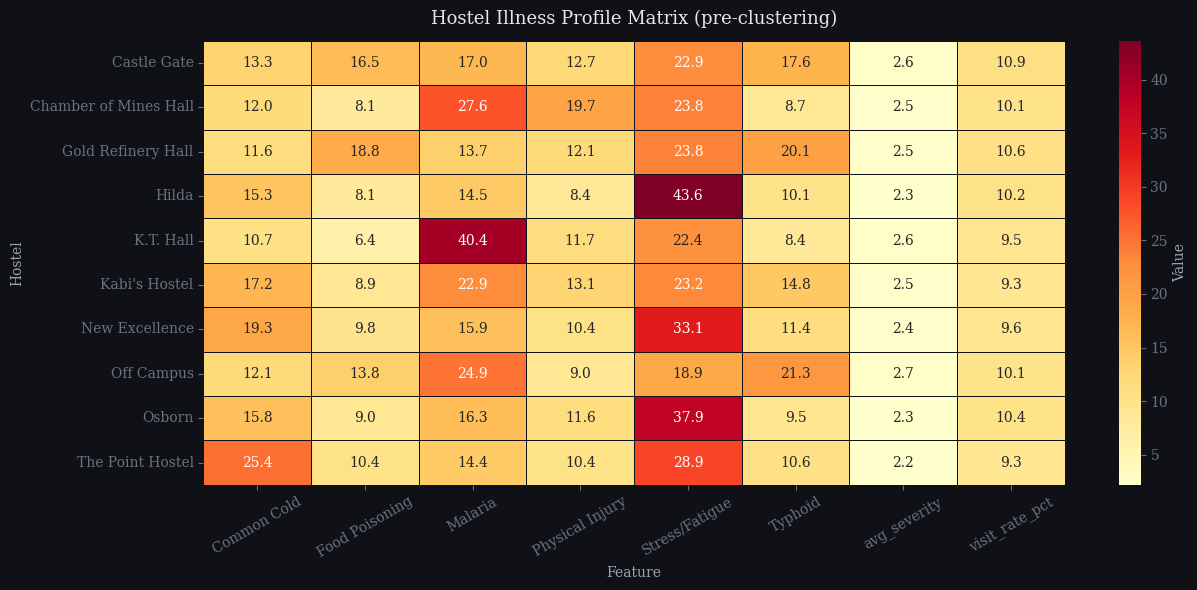

In [4]:
# Heatmap of the hostel profile matrix before clustering
# Reveals the structure the algorithm will be working with

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    hostel_profiles.round(1),
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5, linecolor='#0f1117',
    ax=ax,
    cbar_kws={'label': 'Value'}
)
ax.set_title('Hostel Illness Profile Matrix (pre-clustering)', fontsize=13, pad=12)
ax.set_xlabel('Feature')
ax.set_ylabel('Hostel')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

### A3. Scale the Hostel Features

In [5]:
# StandardScaler: brings all features to the same mathematical scale
# so avg_severity (range ~1–5) doesn't get drowned out by
# illness percentages (range ~0–40)

scaler_hostel = StandardScaler()
hostel_scaled = scaler_hostel.fit_transform(hostel_profiles)

print(f'Scaled matrix shape: {hostel_scaled.shape}')
print(f'Mean after scaling (should be ~0): {hostel_scaled.mean():.4f}')
print(f'Std after scaling  (should be ~1): {hostel_scaled.std():.4f}')

Scaled matrix shape: (10, 8)
Mean after scaling (should be ~0): 0.0000
Std after scaling  (should be ~1): 1.0000


### A4. Find Optimal K - Elbow + Silhouette

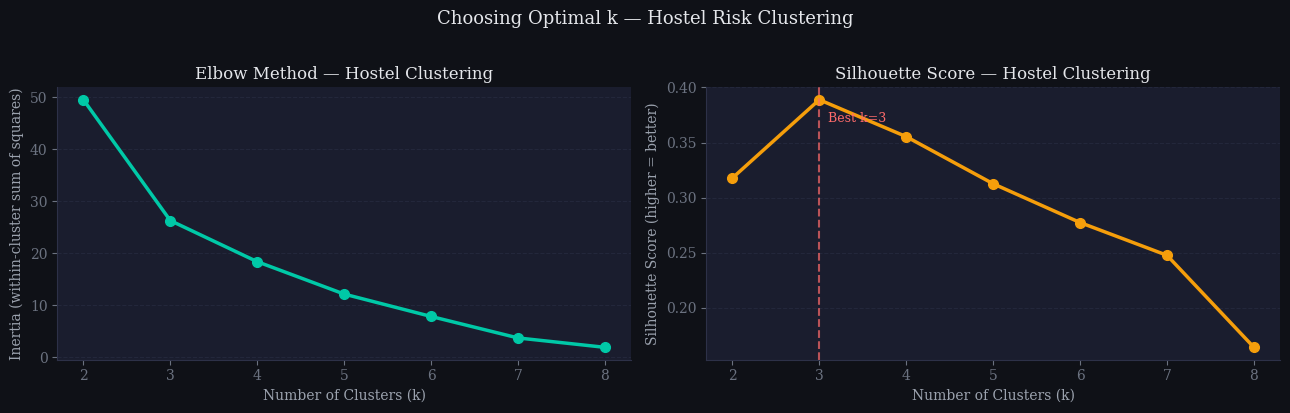

Silhouette scores per k:
  k=2: 0.3178
  k=3: 0.3889
  k=4: 0.3554
  k=5: 0.3126
  k=6: 0.2774
  k=7: 0.2477
  k=8: 0.1642


In [6]:
# Test K = 2 through 8
# With only 10 hostels, going above 8 is meaningless

k_range      = range(2, 9)
inertias_a   = []
silhouettes_a = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(hostel_scaled)
    inertias_a.append(km.inertia_)
    silhouettes_a.append(silhouette_score(hostel_scaled, labels))

# === Plot ===
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Elbow curve
axes[0].plot(list(k_range), inertias_a, color=TEAL, linewidth=2.5,
             marker='o', markersize=7)
axes[0].set_title('Elbow Method — Hostel Clustering', fontsize=12)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].xaxis.set_major_locator(ticker.MultipleLocator(1))
axes[0].grid(axis='y')
axes[0].spines[['top', 'right']].set_visible(False)

# Silhouette scores
axes[1].plot(list(k_range), silhouettes_a, color=AMBER, linewidth=2.5,
             marker='o', markersize=7)
best_k_sil = list(k_range)[silhouettes_a.index(max(silhouettes_a))]
axes[1].axvline(best_k_sil, color=RED, linestyle='--', linewidth=1.5, alpha=0.7)
axes[1].text(best_k_sil + 0.1, max(silhouettes_a) - 0.02,
             f'Best k={best_k_sil}', color=RED, fontsize=9)
axes[1].set_title('Silhouette Score — Hostel Clustering', fontsize=12)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].xaxis.set_major_locator(ticker.MultipleLocator(1))
axes[1].grid(axis='y')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Choosing Optimal k — Hostel Risk Clustering', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Silhouette scores per k:')
for k, s in zip(k_range, silhouettes_a):
    print(f'  k={k}: {s:.4f}')

### A5. Fit Final Model with Chosen K

In [7]:
# === Set K here based on elbow + silhouette plots above ===
K_HOSTEL = 3   # maybe adjusted if ther is time

kmeans_hostel = KMeans(n_clusters=K_HOSTEL, random_state=42, n_init=10)
hostel_profiles['cluster'] = kmeans_hostel.fit_predict(hostel_scaled)

print(f'K-Means A fitted with k={K_HOSTEL}')
print(f'Silhouette score: {silhouette_score(hostel_scaled, hostel_profiles["cluster"]):.4f}')
print()
print('Hostel → Cluster assignments:')
print(hostel_profiles[['cluster']].sort_values('cluster').to_string())

K-Means A fitted with k=3
Silhouette score: 0.3889

Hostel → Cluster assignments:
                       cluster
hostel                        
Chamber of Mines Hall        0
K.T. Hall                    0
Kabi's Hostel                0
Hilda                        1
New Excellence               1
Osborn                       1
The Point Hostel             1
Castle Gate                  2
Off Campus                   2
Gold Refinery Hall           2


### A6. Label the Clusters — Risk Tier Assignment

In [8]:
# Each cluster gets a human-readable risk label based on its profile.
# The label is assigned by looking at which cluster has the highest
# average severity and malaria rate — that one is 'High-Acquity / Malariazone'.
# Adjust the mapping below if cluster numbers differ.

cluster_summary = hostel_profiles.groupby('cluster').mean().round(2)
print('Mean profile per cluster (use this to assign labels):')
print(cluster_summary)
print()

#   Highest avg_severity + highest Malaria → High-Acuity / Malaria Risk
#   Highest Food Poisoning + Typhoid       → Food/Water-Borne Zone
#   Highest Stress/Fatigue                 → Academic Burnout Zone
CLUSTER_LABELS = {
    0: 'High-Acuity / Malaria Risk',
    1: 'Food/Water-Borne Zone',
    2: 'Academic Burnout Zone',
}

hostel_profiles['risk_label'] = hostel_profiles['cluster'].map(CLUSTER_LABELS)

print('Final hostel risk assignments:')
print(hostel_profiles[['cluster', 'risk_label']].sort_values('cluster').to_string())

Mean profile per cluster (use this to assign labels):
         Common Cold  Food Poisoning  Malaria  Physical Injury  \
cluster                                                          
0              13.30            7.76    30.31            14.83   
1              18.95            9.32    15.28            10.20   
2              12.34           16.36    18.52            11.27   

         Stress/Fatigue  Typhoid  avg_severity  visit_rate_pct  
cluster                                                         
0                 23.16    10.63          2.54            9.62  
1                 35.87    10.39          2.30            9.89  
2                 21.86    19.66          2.61           10.52  

Final hostel risk assignments:
                       cluster                  risk_label
hostel                                                    
Chamber of Mines Hall        0  High-Acuity / Malaria Risk
K.T. Hall                    0  High-Acuity / Malaria Risk
Kabi's Hostel         

### A7. Merge Cluster Label Back into Main DataFrame

In [9]:
# Create a lookup: hostel name → risk label
hostel_label_map = hostel_profiles['risk_label'].to_dict()

# Map onto every visit record
df['hostel_risk_cluster'] = df['hostel'].map(hostel_label_map)

print('hostel_risk_cluster added to df ✓')
print()
print('Distribution:')
print(df['hostel_risk_cluster'].value_counts().to_string())
print()
df[['hostel', 'hostel_risk_cluster']].drop_duplicates().sort_values('hostel_risk_cluster')

hostel_risk_cluster added to df ✓

Distribution:
hostel_risk_cluster
Food/Water-Borne Zone         2295
Academic Burnout Zone         1830
High-Acuity / Malaria Risk    1674



,hostel,hostel_risk_cluster
0,Gold Refinery Hall,Academic Burnout Zone
2,Castle Gate,Academic Burnout Zone
5,Off Campus,Academic Burnout Zone
1,The Point Hostel,Food/Water-Borne Zone
10,Hilda,Food/Water-Borne Zone
13,New Excellence,Food/Water-Borne Zone
35,Osborn,Food/Water-Borne Zone
3,Kabi's Hostel,High-Acuity / Malaria Risk
11,K.T. Hall,High-Acuity / Malaria Risk
28,Chamber of Mines Hall,High-Acuity / Malaria Risk


### A8. Visualise — Cluster Bar Chart & PCA Scatter

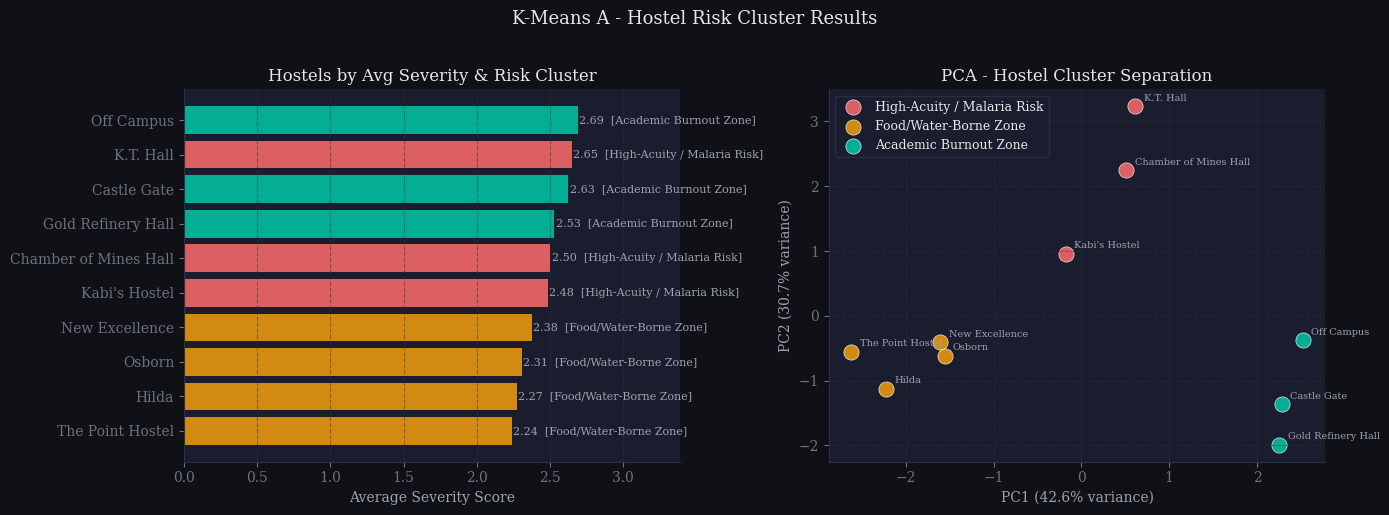

In [10]:
# === Colour map for risk labels ===
risk_colors = {
    'High-Acuity / Malaria Risk':   RED,
    'Food/Water-Borne Zone':   AMBER,
    'Academic Burnout Zone':   TEAL,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# == Left: Hostel risk ranking bar chart ===
hostel_plot = hostel_profiles.reset_index().sort_values('avg_severity', ascending=True)
bar_colors  = [risk_colors[hostel_plot.loc[i, 'risk_label']] for i in hostel_plot.index]

axes[0].barh(
    hostel_plot['hostel'], hostel_plot['avg_severity'],
    color=bar_colors, alpha=0.85, edgecolor='none'
)
for i, (val, label) in enumerate(zip(hostel_plot['avg_severity'], hostel_plot['risk_label'])):
    axes[0].text(val + 0.01, i, f'{val:.2f}  [{label}]',
                 va='center', fontsize=8, color='#9ca3af')

axes[0].set_title('Hostels by Avg Severity & Risk Cluster', fontsize=12)
axes[0].set_xlabel('Average Severity Score')
axes[0].set_xlim(0, hostel_plot['avg_severity'].max() + 0.7)
axes[0].grid(axis='x')
axes[0].spines[['top', 'right']].set_visible(False)

# == Right: PCA scatter ===
pca = PCA(n_components = 2, random_state = 42)
pca_coords = pca.fit_transform(hostel_scaled)
var_explained = pca.explained_variance_ratio_ * 100

for label, color in risk_colors.items():
    mask = hostel_profiles['risk_label'] == label
    axes[1].scatter(
        pca_coords[mask, 0], pca_coords[mask, 1],
        c=color, s=120, alpha=0.85, label=label, edgecolors='white', linewidth=0.5
    )

# Annotate each point with hostel name
for i, hostel_name in enumerate(hostel_profiles.index):
    axes[1].annotate(
        hostel_name, (pca_coords[i, 0], pca_coords[i, 1]),
        textcoords='offset points', xytext=(6, 4),
        fontsize=7, color='#9ca3af'
    )

axes[1].set_title('PCA - Hostel Cluster Separation', fontsize=12)
axes[1].set_xlabel(f'PC1 ({var_explained[0]:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({var_explained[1]:.1f}% variance)')
axes[1].legend(facecolor='#1a1d2e', edgecolor='#2d3148', fontsize=9)
axes[1].grid(True)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('K-Means A - Hostel Risk Cluster Results', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### A9. Cluster Summary Table

In [11]:
# Mean feature values per risk cluster — the interpretable output.
# This is what you present in your report to explain what each cluster means.

summary_a = (
    hostel_profiles
    .groupby('risk_label')
    .mean()
    .round(2)
    .drop(columns=['cluster'])
)

print('=== K-Means A: Cluster Profile Summary ===')
print(summary_a.T.to_string())

=== K-Means A: Cluster Profile Summary ===
risk_label       Academic Burnout Zone  Food/Water-Borne Zone  High-Acuity / Malaria Risk
Common Cold                      12.34                  18.95                       13.30
Food Poisoning                   16.36                   9.32                        7.76
Malaria                          18.52                  15.28                       30.31
Physical Injury                  11.27                  10.20                       14.83
Stress/Fatigue                   21.86                  35.87                       23.16
Typhoid                          19.66                  10.39                       10.63
avg_severity                      2.61                   2.30                        2.54
visit_rate_pct                   10.52                   9.89                        9.62


### A10. Save Hostel Clustering Model

In [12]:
with open('models/kmeans_hostel.pkl', 'wb') as f:
    pickle.dump(kmeans_hostel, f)

with open('models/scaler_hostel.pkl', 'wb') as f:
    pickle.dump(scaler_hostel, f)

# Save the hostel label map for the dashboard to use directly
with open('models/hostel_label_map.pkl', 'wb') as f:
    pickle.dump(hostel_label_map, f)

print('Saved: models/kmeans_hostel.pkl')
print('Saved: models/scaler_hostel.pkl')
print('Saved: models/hostel_label_map.pkl')

Saved: models/kmeans_hostel.pkl
Saved: models/scaler_hostel.pkl
Saved: models/hostel_label_map.pkl


---
## K-Means B - Visit Pattern Discovery

Unit of analysis: the **individual visit** (5,799 rows).  
Goal: discover natural groupings of visit types across the whole dataset.  
Note: `hostel` is excluded here - hostel patterns are handled by K-Means A.  
The `hostel_risk_cluster` column (just created) is included instead.

### B1. Feature Engineering & Encoding

In [13]:
# Select features for visit clustering
# Replace 'month' with the cyclical features
features_b = ['level', 'severity', 'month_sin', 'month_cos', 'gender',
               'department', 'diagnosis', 'hostel_risk_cluster']

df_b = df[features_b].copy()

# One-hot encode all categorical columns
categorical_cols = ['gender', 'department', 'diagnosis', 'hostel_risk_cluster']
df_b_encoded = pd.get_dummies(df_b, columns=categorical_cols)

print(f'Features before encoding : {len(features_b)}')
print(f'Features after encoding  : {df_b_encoded.shape[1]}')
print(f'Rows                     : {df_b_encoded.shape[0]:,}')
print()
print('Encoded columns:')
print(list(df_b_encoded.columns))

Features before encoding : 8
Features after encoding  : 23
Rows                     : 5,799

Encoded columns:
['level', 'severity', 'month_sin', 'month_cos', 'gender_Female', 'gender_Male', 'department_Computer Science & Engineering', 'department_Electrical & Electronic Engineering', 'department_Geological Engineering', 'department_Geomatic Engineering', 'department_Mathematics', 'department_Mechanical Engineering', 'department_Mining Engineering', 'department_Petroleum Engineering', 'diagnosis_Common Cold', 'diagnosis_Food Poisoning', 'diagnosis_Malaria', 'diagnosis_Physical Injury', 'diagnosis_Stress/Fatigue', 'diagnosis_Typhoid', 'hostel_risk_cluster_Academic Burnout Zone', 'hostel_risk_cluster_Food/Water-Borne Zone', 'hostel_risk_cluster_High-Acuity / Malaria Risk']


### B2. Scale the Visit Features

In [14]:
# 1. Scale the encoded categorical data
scaler_visits = StandardScaler()
visits_scaled = scaler_visits.fit_transform(df_b_encoded)

# 2. Apply PCA to create dense continuous features (retain ~90% variance)
# This fixes the Euclidean distance issue for K-Means
pca_pre_cluster = PCA(n_components=0.90, random_state=42)
visits_dense = pca_pre_cluster.fit_transform(visits_scaled)

print(f"Reduced from {visits_scaled.shape[1]} sparse features to {visits_dense.shape[1]} dense components.")
print(f'PCA matrix shape: {visits_dense.shape}')

Reduced from 23 sparse features to 16 dense components.
PCA matrix shape: (5799, 16)


### B3. Find Optimal K - Elbow + Silhouette

  k=2 done — silhouette: 0.0968
  k=3 done — silhouette: 0.1107
  k=4 done — silhouette: 0.1267
  k=5 done — silhouette: 0.1436
  k=6 done — silhouette: 0.1400
  k=7 done — silhouette: 0.1398
  k=8 done — silhouette: 0.2318
  k=9 done — silhouette: 0.2178
  k=10 done — silhouette: 0.2032


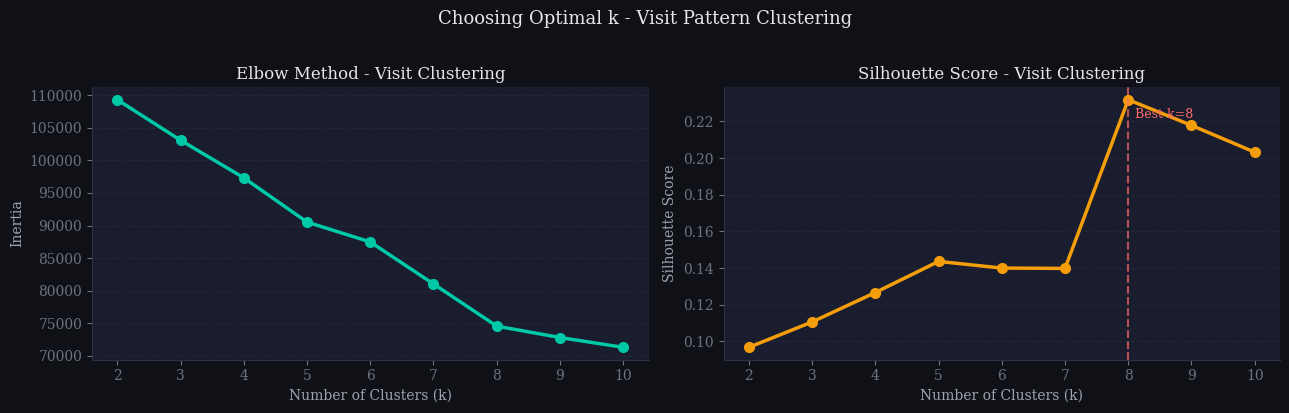

In [15]:
k_range       = range(2, 11)
inertias_b    = []
silhouettes_b = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(visits_dense)
    inertias_b.append(km.inertia_)
    silhouettes_b.append(silhouette_score(visits_dense, labels,
                                          sample_size=2000, random_state=42))
    print(f'  k={k} done — silhouette: {silhouettes_b[-1]:.4f}')

# === Plot ===
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(k_range), inertias_b, color=TEAL, linewidth=2.5,
             marker='o', markersize=7)
axes[0].set_title('Elbow Method - Visit Clustering', fontsize=12)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].xaxis.set_major_locator(ticker.MultipleLocator(1))
axes[0].grid(axis='y')
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].plot(list(k_range), silhouettes_b, color=AMBER, linewidth=2.5,
             marker='o', markersize=7)
best_k_b = list(k_range)[silhouettes_b.index(max(silhouettes_b))]
axes[1].axvline(best_k_b, color=RED, linestyle='--', linewidth=1.5, alpha=0.7)
axes[1].text(best_k_b + 0.1, max(silhouettes_b) - 0.01,
             f'Best k={best_k_b}', color=RED, fontsize=9)
axes[1].set_title('Silhouette Score - Visit Clustering', fontsize=12)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].xaxis.set_major_locator(ticker.MultipleLocator(1))
axes[1].grid(axis='y')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Choosing Optimal k - Visit Pattern Clustering', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### B4. Fit Final Model with Chosen K

In [16]:
# === Set K here based on elbow + silhouette plots above ===
# 4 will be used so as to not have a lot of profiles to monitor
K_VISITS = 4   # adjustable if plots suggest otherwise 

# 1. Scale the data
scaler_visits = StandardScaler()
visits_scaled = scaler_visits.fit_transform(df_b_encoded)

# 2. Appling PCA to create dense continuous features (retain ~90% variance)
# This fixes the Euclidean distance issue on one-hot data
pca_pre_cluster = PCA(n_components=0.90, random_state=42)
visits_dense = pca_pre_cluster.fit_transform(visits_scaled)

print(f"Reduced from {visits_scaled.shape[1]} sparse features to {visits_dense.shape[1]} dense components.")

# 3. Run K-Means on the dense PCA components, NOT the scaled binary data
kmeans_visits = KMeans(n_clusters=K_VISITS, random_state=42, n_init=10)
df['visit_cluster'] = kmeans_visits.fit_predict(visits_dense)

print(f'K-Means B fitted with k={K_VISITS}')
print(f'Silhouette score: {silhouette_score(visits_dense, df["visit_cluster"], sample_size=2000, random_state=42):.4f}')
print()
print('Records per cluster:')
print(df['visit_cluster'].value_counts().sort_index().to_string())

Reduced from 23 sparse features to 16 dense components.
K-Means B fitted with k=4
Silhouette score: 0.1267

Records per cluster:
visit_cluster
0     691
1    2498
2    1195
3    1415


### B5. Profile Each Visit Cluster

In [17]:
# What does each cluster look like?
# For each cluster: most common diagnosis, hostel risk tier,
# dominant level, average severity, dominant month.

cluster_profiles_b = df.groupby('visit_cluster').agg(
    top_diagnosis   = ('diagnosis',           lambda x: x.value_counts().idxmax()),
    top_hostel_risk = ('hostel_risk_cluster',  lambda x: x.value_counts().idxmax()),
    top_level       = ('level',               lambda x: x.value_counts().idxmax()),
    top_department  = ('department',          lambda x: x.value_counts().idxmax()),
    avg_severity    = ('severity',            'mean'),
    avg_month       = ('month',               'mean'),
    record_count    = ('severity',            'count'),
).round(2)

print('------ K-Means B: Visit Cluster Profiles ----------------------------------------------')
print(cluster_profiles_b.to_string())

------ K-Means B: Visit Cluster Profiles ----------------------------------------------
                 top_diagnosis             top_hostel_risk  top_level                  top_department  avg_severity  avg_month  record_count
visit_cluster                                                                                                                               
0              Physical Injury  High-Acuity / Malaria Risk        400          Mechanical Engineering          2.60       5.70           691
1               Stress/Fatigue       Food/Water-Borne Zone        400  Computer Science & Engineering          1.70       6.17          2498
2                      Malaria  High-Acuity / Malaria Risk        100              Mining Engineering          3.18       6.19          1195
3                      Typhoid       Academic Burnout Zone        200          Geological Engineering          3.16       6.07          1415


### B6. Label the Visit Clusters

In [18]:
# After reading the profile table above, assign a descriptive name
# to each cluster. Examples based on expected patterns:
#   'Exam Stress Cases'   — high Stress/Fatigue, low severity, Level 400
#   'Tropical Illness'    — Malaria/Typhoid dominant, high severity
#   'Fresher Burnout'     — Level 100, early months, Malaria + Cold
#   'Minor Ailments'      — Common Cold, low severity, mixed levels

# ── Edit this dict to match your actual cluster numbers ───────
VISIT_CLUSTER_LABELS = {
    0: 'Tropical Illness',
    1: 'Severe/Water-Borne',
    2: 'Fresher Burnout',
    3: 'Minor Ailments',
}

df['visit_cluster_label'] = df['visit_cluster'].map(VISIT_CLUSTER_LABELS)

print('visit_cluster_label added to df ✓')
print()
print(df['visit_cluster_label'].value_counts().to_string())

visit_cluster_label added to df ✓

visit_cluster_label
Severe/Water-Borne    2498
Minor Ailments        1415
Fresher Burnout       1195
Tropical Illness       691


### B7. Visualise - PCA Scatter of Visit Clusters

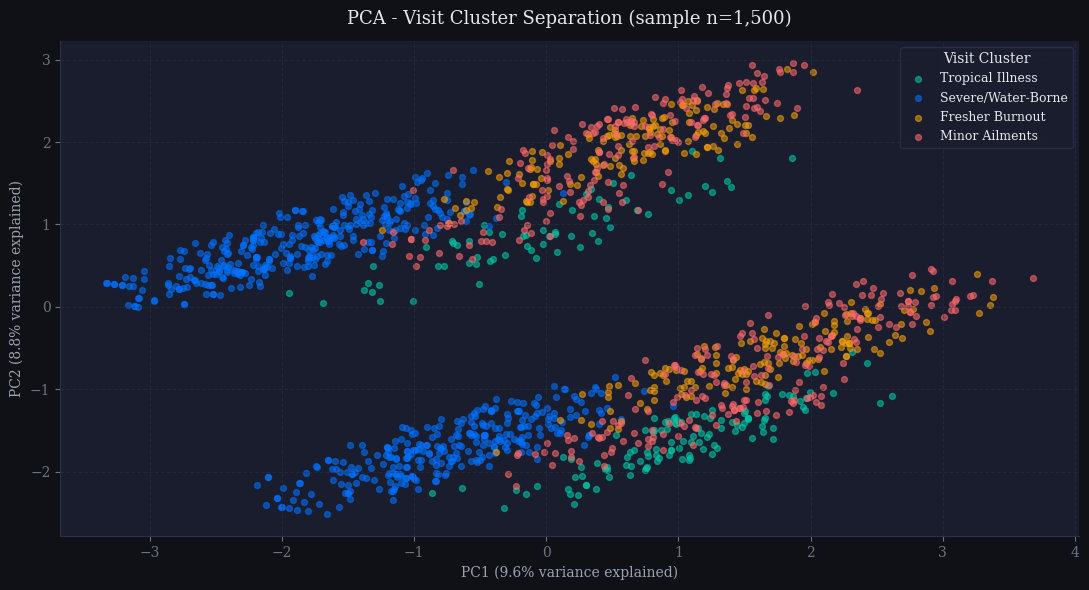

In [19]:
# PCA reduces the high-dimensional encoded space to 2D for visualisation
# Sample 1500 points for readability

sample_idx   = np.random.choice(len(visits_scaled), size=1500, replace=False)
pca_b        = PCA(n_components=2, random_state=42)
pca_b_coords = pca_b.fit_transform(visits_scaled[sample_idx])
sample_labels= df['visit_cluster_label'].iloc[sample_idx].values
var_b        = pca_b.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(11, 6))

unique_labels = list(VISIT_CLUSTER_LABELS.values())
for label, color in zip(unique_labels, PALETTE):
    mask = sample_labels == label
    ax.scatter(
        pca_b_coords[mask, 0], pca_b_coords[mask, 1],
        c=color, s=18, alpha=0.55, label=label
    )

ax.set_title('PCA - Visit Cluster Separation (sample n=1,500)', fontsize=13, pad=12)
ax.set_xlabel(f'PC1 ({var_b[0]:.1f}% variance explained)')
ax.set_ylabel(f'PC2 ({var_b[1]:.1f}% variance explained)')
ax.legend(title='Visit Cluster', facecolor='#1a1d2e',
          edgecolor='#2d3148', fontsize=9)
ax.grid(True)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### B8. Save Visit Clustering Model

In [20]:
with open('models/kmeans_visits.pkl', 'wb') as f:
    pickle.dump(kmeans_visits, f)

with open('models/scaler_visits.pkl', 'wb') as f:
    pickle.dump(scaler_visits, f)

with open('models/visit_cluster_labels.pkl', 'wb') as f:
    pickle.dump(VISIT_CLUSTER_LABELS, f)

# Save encoded column names — needed to align new data at prediction time
with open('models/visit_feature_columns.pkl', 'wb') as f:
    pickle.dump(list(df_b_encoded.columns), f)

print('Saved: models/kmeans_visits.pkl')
print('Saved: models/scaler_visits.pkl')
print('Saved: models/visit_cluster_labels.pkl')
print('Saved: models/visit_feature_columns.pkl')

Saved: models/kmeans_visits.pkl
Saved: models/scaler_visits.pkl
Saved: models/visit_cluster_labels.pkl
Saved: models/visit_feature_columns.pkl


---
## Final Step — Save Enriched DataFrame to MongoDB

The original 7-column records are replaced with 9-column records:  
`+ hostel_risk_cluster` + `visit_cluster_label`  

The dashboard and regression phase read from this enriched collection.

In [ ]:
# Convert dates back to strings for clean MongoDB storage
df_to_save = df.copy()
df_to_save['visit_date'] = df_to_save['visit_date'].dt.strftime('%Y-%m-%d')

# Drop the integer visit_cluster — label version is more useful
df_to_save = df_to_save.drop(columns=['visit_cluster'])

# Create a dedicated collection for Phase 4 & 5 to read from
enriched_collection = db['clinic_logs_enriched']

# Drop ONLY the enriched collection if we are rerunning the notebook
enriched_collection.drop()

# Insert the new data safely without touching the raw 'clinic_logs'
enriched_collection.insert_many(df_to_save.to_dict('records'))

print(f"MongoDB safely updated ✓")
print(f"New Collection : clinic_logs_enriched")

print(f'MongoDB updated ✓')
print(f'Collection : clinic_logs')
print(f'Records    : {collection.count_documents({}):,}')
print(f'New columns: hostel_risk_cluster, visit_cluster_label')
print()

# Verify
sample = pd.DataFrame(list(collection.find({}, {'_id': 0}).limit(3)))
print('Sample record from MongoDB:')
print(sample.to_string())

MongoDB safely updated ✓
New Collection : clinic_logs_enriched
MongoDB updated ✓
Collection : clinic_logs
Records    : 5,799
New columns: hostel_risk_cluster, visit_cluster_label

Sample record from MongoDB:
  visit_date  level  gender                           department              hostel        diagnosis  severity
0 2024-01-15    200    Male  Electrical & Electronic Engineering  Gold Refinery Hall  Physical Injury         1
1 2024-01-15    400  Female  Electrical & Electronic Engineering    The Point Hostel   Stress/Fatigue         3
2 2024-01-15    400  Female       Computer Science & Engineering         Castle Gate   Food Poisoning         2


: 

---
## Clustering Summary

| Model | Input | K | Silhouette | Output column |
|---|---|---|---|---|
| K-Means A (Hostel) | 10 × 8 profile matrix | 3 | — | `hostel_risk_cluster` |
| K-Means B (Visits) | 5,839 × N encoded matrix | 4 | — | `visit_cluster_label` |

**Next:** Phase 4 — Regression to predict visit severity.